<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/15_Eigendecomposition_and_SVD_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 15: Eigendecomposition and SVD Applications

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Materi
Bab ini mengintegrasikan pengetahuan eigendecomposition dan SVD ke dalam aplikasi tingkat lanjut. Kita mempelajari bagaimana teknik aljabar linear ini membentuk fondasi dari algoritma pembelajaran mesin tanpa pengawasan, seperti PCA untuk reduksi dimensi dan LDA untuk klasifikasi, serta teknik pembersihan data melalui aproksimasi rank rendah.

### Topik yang Dibahas:
1. Matematika di balik PCA
2. Implementasi PCA via SVD
3. Linear Discriminant Analysis (LDA) secara matematis
4. Denoising data melalui SVD


***
## Principal Component Analysis (PCA)

### Penjelasan Teori
PCA bertujuan mencari sumbu koordinat baru yang memaksimalkan varians data. Secara matematis, PCA dapat dilakukan dengan dua cara: menghitung vektor eigen dari matriks kovarians (Eigendecomposition) atau menggunakan SVD langsung pada data yang telah dipusatkan (mean centered). SVD umumnya lebih disukai dalam implementasi perangkat lunak karena stabilitas numeriknya yang lebih tinggi.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulasi Data Terkorelasi
np.random.seed(42)
data = np.dot(np.random.randn(100, 2), np.array([[2, 1], [1, 2]]))
data_centered = data - np.mean(data, axis=0)

# 2. PCA via SVD
U, S, VT = np.linalg.svd(data_centered, full_matrices=False)

# Vektor eigen adalah kolom dari V (yaitu baris dari VT)
pca_components = VT.T

print("Komponen Utama (Vektor Eigen):\n", pca_components)


Komponen Utama (Vektor Eigen):
 [[-0.66726433  0.744821  ]
 [-0.744821   -0.66726433]]


***
## Linear Discriminant Analysis (LDA)

### Penjelasan Teori
Berbeda dengan PCA yang tidak memperhatikan label kelas, LDA menggunakan label kelas untuk mencari proyeksi yang memaksimalkan jarak antara rata rata kelompok sekaligus meminimalkan penyebaran di dalam kelompok itu sendiri. Ini dilakukan dengan memecahkan masalah eigen umum: $S_w^{-1} S_b v = \lambda v$.



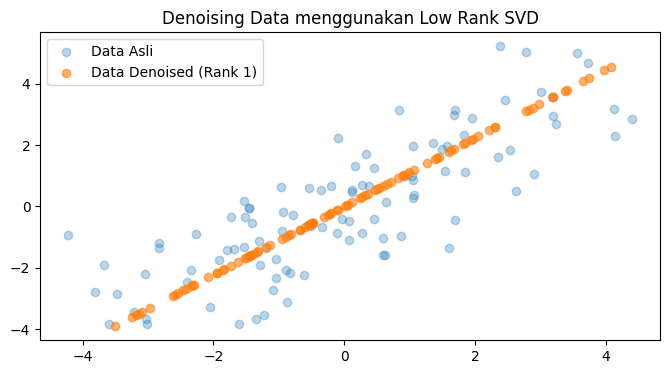

In [2]:
# 3. Low Rank Approximation (SVD untuk Denoising)
# Kita menggunakan hanya satu komponen utama untuk merekonstruksi data
k = 1
data_denoised = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

plt.figure(figsize=(8, 4))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.3, label='Data Asli')
plt.scatter(data_denoised[:, 0], data_denoised[:, 1], alpha=0.6, label='Data Denoised (Rank 1)')
plt.legend()
plt.title('Denoising Data menggunakan Low Rank SVD')
plt.show()
